In [1]:
import numpy as np
from chmm_actions import CHMM, forwardE, datagen_zhao2025
import matplotlib.pyplot as plt
import igraph
from matplotlib import cm, colors
import os
import copy

custom_colors = (
        [
            '#FFFFFF', 
            '#E596B6',
            '#80B8D3', 
            "#F1A611",
            '#78BC97',
            '#9D9D9D', 
            '#000000'
        ]
    )
    
seed = 45
plot_seed = 0
num_clone = 100
par_reg = 1e-6

In [2]:

def get_mess_fwd(chmm, x, pseudocount=0.0, pseudocount_E=0.0):
    n_clones = chmm.n_clones
    E = np.zeros((n_clones.sum(), len(n_clones)))
    last = 0
    for c in range(len(n_clones)):
        E[last : last + n_clones[c], c] = 1
        last += n_clones[c]
    E += pseudocount_E
    norm = E.sum(1, keepdims=True)
    norm[norm == 0] = 1
    E /= norm
    T = chmm.C + pseudocount
    norm = T.sum(2, keepdims=True)
    norm[norm == 0] = 1
    T /= norm
    T = T.mean(0, keepdims=True)
    log2_lik, mess_fwd = forwardE(
        T.transpose(0, 2, 1), E, chmm.Pi_x, chmm.n_clones, x, x * 0, store_messages=True
    )
    return mess_fwd


def place_field(mess_fwd, rc, clone):
    assert mess_fwd.shape[0] == rc.shape[0] and clone < mess_fwd.shape[1]
    field = np.zeros(rc.max(0) + 1)
    count = np.zeros(rc.max(0) + 1, int)
    for t in range(mess_fwd.shape[0]):
        r, c = rc[t]
        field[r, c] += mess_fwd[t, clone]
        count[r, c] += 1
    count[count == 0] = 1
    return field / count


In [3]:
def transition_graph_plotter(chmm, x, a, axs, seed=0, cmap=cm.Spectral):
    chmm.pseudocount = 0.0
    chmm.learn_viterbi_T(x, a, n_iter=100)
    states = chmm.decode(x, a)[1]
    v = np.unique(states)
    
    T = chmm.C[:, v][:, :, v]
    A = T.sum(0)
    A /= A.sum(1, keepdims=True)

    g = igraph.Graph.Adjacency((A > 0).tolist())
    node_labels = np.arange(x.max() + 1).repeat(n_clones)[v]
    colors = [cmap(nl)[:] for nl in node_labels / node_labels.max()]
    igraph.plot(g,
                layout = g.layout('fr'),
                vertex_color= colors, 
                vertex_size=15, 
                target= axs,
                edge_curved=0,
                edge_arrow_size=5,
                edge_arrow_width=5,
                edge_width=1,
                margin=30,
                seed = seed
                ) 

In [4]:
# room1 = np.array(
#     [
#         [0, 0, 0, 1, 4, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 5, 5],     #AB_
#         [0, 0, 0, 1, 4, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 5, 5],     #A_B
#         [0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 1, 4, 0, 0, 0, 5, 5],     #B_A
#         [0, 0, 0, 2, 2, 0, 0, 1, 4, 0, 0, 0, 0, 0, 0, 0, 5, 5],     #BA_
#         [0, 0, 0, 0, 0, 0, 0, 1, 4, 0, 0, 2, 2, 0, 0, 0, 5, 5],     #_AB       
#         [0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 1, 4, 0, 0, 0, 5, 5],     #_BA  
#     ]  
# )    
room2 = np.array(
    [
        [4, 0, 0, 0, 1, 1, 0, 0, 2, 2, 0, 0, 1, 1, 0, 0, 0, 5, 6, 6],     #ABC
        [4, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 2, 2, 0, 0, 0, 5, 6, 6],     #ACB
        [4, 0, 0, 0, 2, 2, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 5, 6, 6],     #BCA
        [4, 0, 0, 0, 2, 2, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 5, 6, 6],     #BAC
        [4, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 2, 2, 0, 0, 0, 5, 6, 6],     #CAB       
        [4, 0, 0, 0, 1, 1, 0, 0, 2, 2, 0, 0, 1, 1, 0, 0, 0, 5, 6, 6],     #CBA
        
    ]
)

n_emissions = room2.max() + 1
obs = len(np.unique(room2[0]))

seed = seed
a1, x1, rc1 = datagen_zhao2025(room2, length=1000, seed=seed)
a2, x2, rc2 = datagen_zhao2025(room2, length=1000, seed=seed)
n_clones = np.ones(n_emissions, dtype=np.int64) * num_clone

In [5]:
chmm = CHMM(n_clones=n_clones, pseudocount=par_reg, x=x1, a=a1, seed=seed)  # Initialize the model

  0%|          | 0/100 [00:00<?, ?it/s]

  3%|▎         | 3/100 [00:00<00:02, 37.14it/s, train_bps=0.0845]


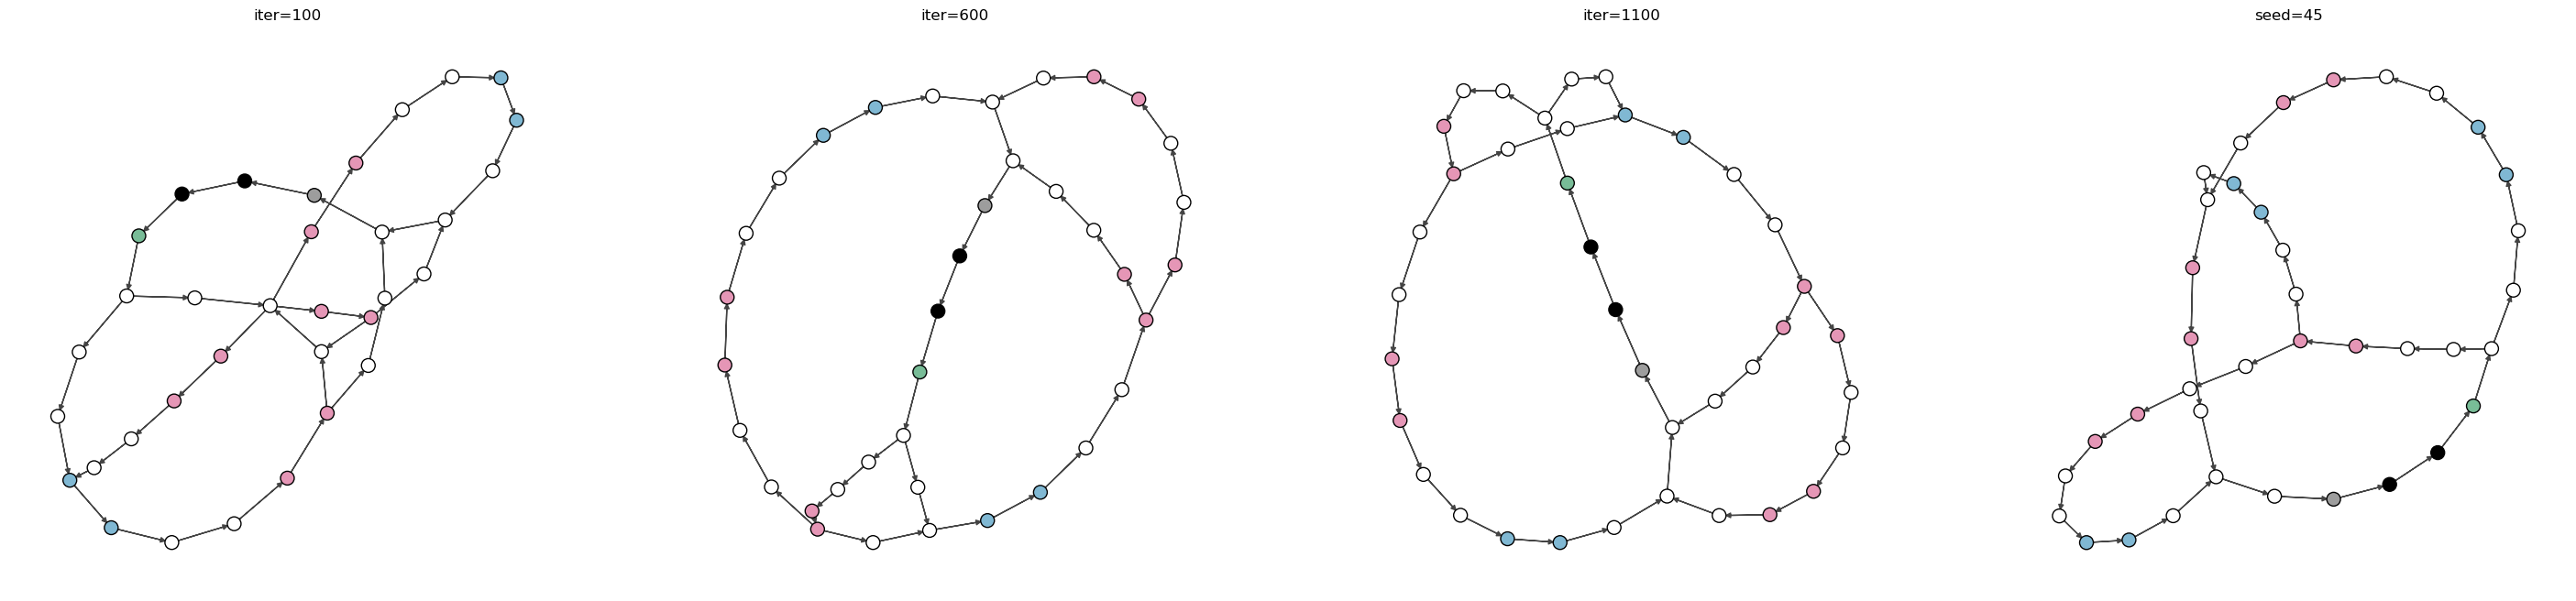

In [6]:
chmm.pseudocount=par_reg
axs_counter = 0
cmap = colors.ListedColormap(custom_colors)
fig, axs = plt.subplots(1,4,figsize = (36, 8))
x,a=x1,a1
for tot_iter in range(0,21):
    progression = chmm.learn_em_T(x, a, n_iter=100, term_early=False)  # Training

    if tot_iter in [0, 5, 10, 20]:
        chmm_curr = copy.deepcopy(chmm)
        transition_graph_plotter(chmm_curr,x1,a1,axs[axs_counter], seed=plot_seed, cmap=cmap)
        axs[axs_counter].set_title(f'iter={(tot_iter+1) * 100}')
        axs_counter =  axs_counter + 1
plt.title(f'seed={seed}')
fig.savefig('../plot/fig/no_reg_cscg.svg', format='svg')

  1%|          | 1/100 [00:00<00:04, 23.56it/s, train_bps=0.0845]


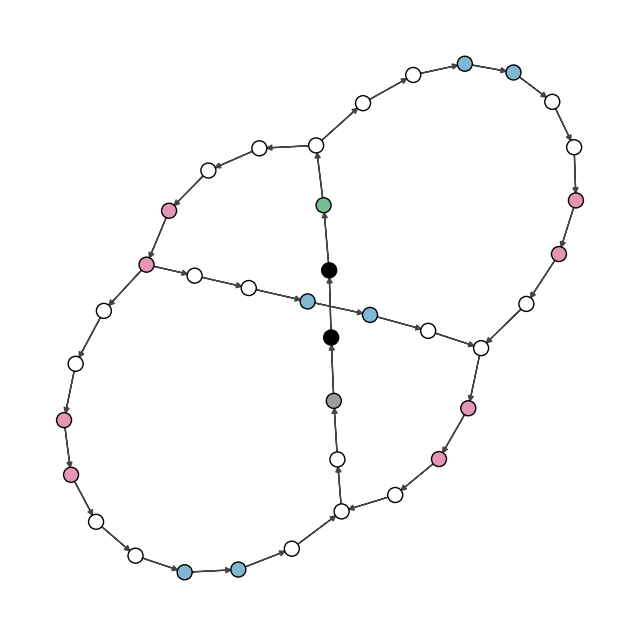

In [7]:
fig, axs= plt.subplots(1, 1, figsize=(8,8))
transition_graph_plotter(chmm_curr,x2,a2,axs, seed=4, cmap=cmap)
fig.savefig('../plot/fig/cscg.svg', format='svg')

In [8]:
nll_per_prediction = chmm.bps(
    x2, a2
)  # Evaluate negative log-likelihood (base 2 log)
avg_nll = np.mean(nll_per_prediction)
avg_prediction_probability = 2 ** (-avg_nll)
print(avg_prediction_probability)

0.9463868938237445


In [9]:
def get_mess_fwd(chmm, x, pseudocount=0.0, pseudocount_E=0.0):
    n_clones = chmm.n_clones
    E = np.zeros((n_clones.sum(), len(n_clones)))
    last = 0
    for c in range(len(n_clones)):
        E[last : last + n_clones[c], c] = 1
        last += n_clones[c]
    E += pseudocount_E
    norm = E.sum(1, keepdims=True)
    norm[norm == 0] = 1
    E /= norm
    T = chmm.C + pseudocount
    norm = T.sum(2, keepdims=True)
    norm[norm == 0] = 1
    T /= norm
    T = T.mean(0, keepdims=True)
    log2_lik, mess_fwd = forwardE(
        T.transpose(0, 2, 1), E, chmm.Pi_x, chmm.n_clones, x, x * 0, store_messages=True
    )
    return mess_fwd
